In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return 0.001 * x * x + 0.1 * np.random.randn(*x.shape)

x = np.arange(-100, 100)    
y = f(x)
plt.plot(x, y)

In [ ]:
from torch import nn
import torch


class RNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim = 16, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.fc = nn.Sequential(nn.Linear(input_dim + hidden_dim, 16), nn.ELU(), nn.Linear(16, hidden_dim))
        self.fc_out = nn.Sequential(nn.ELU(), nn.Linear(hidden_dim, output_dim))
        
    def forward(self, x, tf_mask=None):
        if tf_mask is None:
            tf_mask = torch.ones(len(x))

        h  = torch.zeros((x.shape[1], self.input_dim))
        out = torch.zeros((len(x), self.output_dim))
        out_prev = x[0] 

        for idx, ele in enumerate(x):
            inpt = tf_mask[idx] * ele + (1 - tf_mask[idx]) * out_prev
            h = self.fc.forward(torch.cat([inpt, h], dim=1))
            out[idx] = self.fc_out.forward(h)
            out_prev = out[idx]
        return out, h
    
    
    def delta_forward(self, x, tf_mask=None): 
        # x (seq_len, batch_size, n_features)
        if tf_mask is None:
            tf_mask = torch.ones(len(x))
        h  = torch.zeros((x.shape[1], self.input_dim))
        state_preds = torch.zeros((len(x), self.output_dim))
        prev_state_pred = x[0]
        
        for idx, gt_prev_state in enumerate(x):
            prev_state = tf_mask[idx] * gt_prev_state + (1 - tf_mask[idx]) * prev_state_pred
            
            h = self.fc.forward(torch.cat([prev_state, h], dim=1))
            pred_delta = self.fc_out.forward(h)
            
            pred_state = prev_state + pred_delta
            state_preds[idx] = pred_state
            
            prev_state_pred = pred_state
        return state_preds, h


rnn  = RNN(16, 16)
x = torch.randn((10, 16))  # (seq_len, features)
tf_mask = (torch.rand(10) > 0.1).int()
tf_mask[0] = 1

rnn.forward(x[:, None], tf_mask) 


def ts_split(x, window_length: int):
    res = []
    for i in range(window_length):
        cut_ts = x[i:]
        n_splits = int(cut_ts.shape[0] / window_length)
        cut_ts = cut_ts[:n_splits * window_length]
        splitted = np.split(cut_ts, np.linspace(0, len(cut_ts), n_splits, endpoint=False)[1:].astype(int))
        res.extend(splitted)
        
    res = np.stack(res)
    return res

X = torch.from_numpy(ts_split(y, 10)).float()

rnn = RNN(1, 1)
rnn.forward(X.T[..., None])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (191x2 and 17x16)

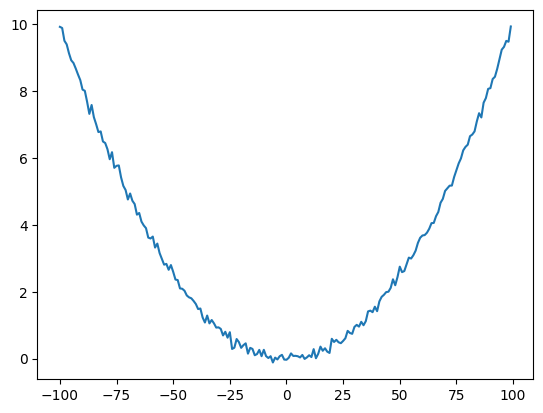

In [63]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return 0.001 * x * x + 0.1 * np.random.randn(*x.shape)

x = np.arange(-100, 100)
y = f(x)
plt.plot(x, y)

In [67]:
def ts_split(x, window_length: int):
    res = []
    for i in range(window_length):
        cut_ts = x[i:]
        n_splits = int(cut_ts.shape[0] / window_length)
        cut_ts = cut_ts[:n_splits * window_length]
        splitted = np.split(cut_ts, np.linspace(0, len(cut_ts), n_splits, endpoint=False)[1:].astype(int))
        res.extend(splitted)
        
    res = np.stack(res)
    return res

X = torch.from_numpy(ts_split(y, 10)).float()

rnn = RNN(1, 1)
rnn.forward(X.T[..., None])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (191x2 and 17x16)